# Flower Classification Notebook: SIFT + RandomForest
This notebook implements the complete training and evaluation pipeline using real dataset inputs split into Train, Validation, and Test subsets.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Configurations
DATASET_DIR = "flower-training"
CLASSES = ["bellflower", "daisy", "dandelion", "lotus", "rose", "sunflower", "tulip"]
FEATURE_NAME = "SIFT"
CLASSIFIER_NAME = "RandomForest"
# We set a default limit of 150 images per class for fast, crash-free execution in notebooks.
# Set LIMIT_PER_CLASS = None to run on the entire dataset.
LIMIT_PER_CLASS = 150


## 1. Image Preprocessing (3 Steps)
- **Step 1:** Resize image to $256 \times 256$ pixels.
- **Step 2:** Apply Gaussian Blur filter ($5 \times 5$ kernel).
- **Step 3:** Apply HSV-based Green color removal mask to extract the flower region.

In [3]:
def preprocess_single_image(img, targetedSize=(256, 256)):
    resized_img = cv2.resize(img, targetedSize, interpolation=cv2.INTER_LINEAR)
    blurred_img = cv2.GaussianBlur(resized_img, (5, 5), 0)
    return blurred_img

def extract_flower_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_green = np.array([18, 40, 40])
    upper_green = np.array([43, 255, 255])
    green_mask = cv2.inRange(hsv, lower_green, upper_green)
    flower_mask = cv2.bitwise_not(green_mask)
    return flower_mask

## 2. Feature Extraction
- Keypoint descriptor extractor (SIFT/ORB)
- HSV Color histogram feature extractor

In [4]:
class DescriptorService:
    def __init__(self):
        self.extractor = cv2.SIFT_create(nfeatures=500)
        
    def extract_features(self, image, mask=None):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        _, descriptors = self.extractor.detectAndCompute(gray, mask)
        if descriptors is None:
            return np.zeros((0, 128), dtype=np.float32)
        return descriptors.astype(np.float32)

def extract_hsv_histogram(image, mask=None):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], mask, [8, 4, 4], [0, 180, 0, 256, 0, 256])
    hist_flat = hist.flatten()
    norm = np.linalg.norm(hist_flat, ord=2)
    if norm > 0:
        hist_flat /= norm
    return hist_flat

## 3. Dataset Loading and Initial Splits
Load real images from the `flower-training` directory, preprocess them, and split into train/test.

In [5]:
print("Loading dataset...")
image_paths = []
labels = []

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    count = 0
    for filename in os.listdir(cls_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, filename))
            labels.append(label_idx)
            count += 1
            if LIMIT_PER_CLASS is not None and count >= LIMIT_PER_CLASS:
                break

print(f"Loaded {len(image_paths)} images from {len(CLASSES)} classes.")

# Split: Train (80%) and Test (20%)
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Further split Train into Train (90% of Train) and Validation (10% of Train)
# This results in 72% Train, 8% Val, 20% Test of overall dataset
X_tr_paths, X_val_paths, y_tr, y_val = train_test_split(
    X_train_paths, y_train, test_size=0.1, stratify=y_train, random_state=42
)

print(f"Train size: {len(X_tr_paths)}, Val size: {len(X_val_paths)}, Test size: {len(X_test_paths)}")

Loading dataset...
Loaded 1050 images from 7 classes.
Train size: 756, Val size: 84, Test size: 210


## 4. Feature Extraction & BoVW Vocabulary Fitting
Fit K-Means vocabulary ONLY on the training descriptors, then compute fused BoVW + HSV Histograms for all subsets.

In [6]:
descriptor_service = DescriptorService()

def get_descriptors_and_colors(paths):
    descs_list = []
    colors_list = []
    for path in paths:
        img = cv2.imread(path)
        if img is None:
            descs_list.append(None)
            colors_list.append(np.zeros(128, dtype=np.float32))
            continue
        cleaned = preprocess_single_image(img)
        mask = extract_flower_mask(cleaned)
        descs = descriptor_service.extract_features(cleaned, mask=mask)
        color = extract_hsv_histogram(cleaned, mask=mask)
        descs_list.append(descs)
        colors_list.append(color)
    return descs_list, colors_list

print("Extracting training features...")
train_descs, train_colors = get_descriptors_and_colors(X_tr_paths)
print("Extracting validation features...")
val_descs, val_colors = get_descriptors_and_colors(X_val_paths)
print("Extracting test features...")
test_descs, test_colors = get_descriptors_and_colors(X_test_paths)

# Fit Visual Vocabulary (K-Means) on training descriptors
print("Fitting K-Means visual vocabulary...")
flat_train_descs = [d for d in train_descs if d is not None and len(d) > 0]
all_train_descs = np.vstack(flat_train_descs)
kmeans = MiniBatchKMeans(n_clusters=300, random_state=42, batch_size=1000, n_init="auto")
kmeans.fit(all_train_descs)

def fuse_features(descriptors, color_hist):
    # transform to vocabulary histogram
    histogram = np.zeros(300, dtype=np.float32)
    if descriptors is not None and len(descriptors) > 0:
        words = kmeans.predict(descriptors)
        for w in words:
            histogram[w] += 1.0
    norm1 = np.linalg.norm(histogram, ord=1)
    if norm1 > 0:
        histogram /= norm1
        
    # normalize color
    hist_l2 = histogram / (np.linalg.norm(histogram, ord=2) + 1e-6)
    color_l2 = color_hist / (np.linalg.norm(color_hist, ord=2) + 1e-6)
    
    # fuse
    fused = np.hstack([hist_l2, 0.5 * color_l2])
    fused /= np.linalg.norm(fused, ord=2) + 1e-6
    return fused

print("Fusing features...")
X_train_fused = np.array([fuse_features(train_descs[i], train_colors[i]) for i in range(len(X_tr_paths))])
X_val_fused = np.array([fuse_features(val_descs[i], val_colors[i]) for i in range(len(X_val_paths))])
X_test_fused = np.array([fuse_features(test_descs[i], test_colors[i]) for i in range(len(X_test_paths))])
y_train = np.array(y_tr)
y_val = np.array(y_val)
y_test = np.array(y_test)

Extracting training features...

Extracting validation features...


Extracting test features...


Fitting K-Means visual vocabulary...


Fusing features...


## 5. Model Training

In [7]:

# Train RandomForest model
print("Training RandomForest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_fused, y_train)


Training RandomForest Classifier...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

## 6. Model Evaluation
Print classification report and plot confusion matrix.

--- Classification Report: SIFT + RandomForest ---
              precision    recall  f1-score   support

  bellflower       0.82      0.90      0.86        30
       daisy       0.76      0.63      0.69        30
   dandelion       0.62      0.70      0.66        30
       lotus       0.74      0.77      0.75        30
        rose       0.53      0.57      0.55        30
   sunflower       0.71      0.80      0.75        30
       tulip       0.52      0.37      0.43        30

    accuracy                           0.68       210
   macro avg       0.67      0.68      0.67       210
weighted avg       0.67      0.68      0.67       210



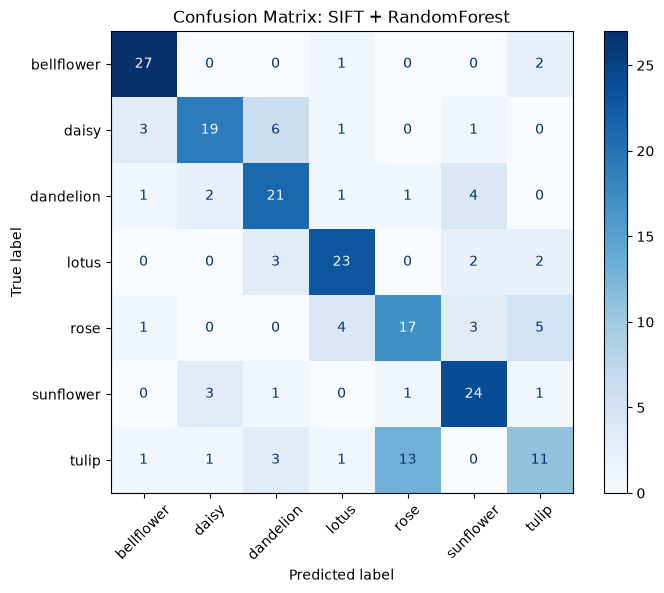

In [8]:
preds = model.predict(X_test_fused)
print(f"--- Classification Report: {FEATURE_NAME} + {CLASSIFIER_NAME} ---")
print(classification_report(y_test, preds, target_names=CLASSES))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix: {FEATURE_NAME} + {CLASSIFIER_NAME}")
plt.show()

## 7. Iterative Training: Accuracy and Loss Curves

Evaluating model performance vs number of estimators...


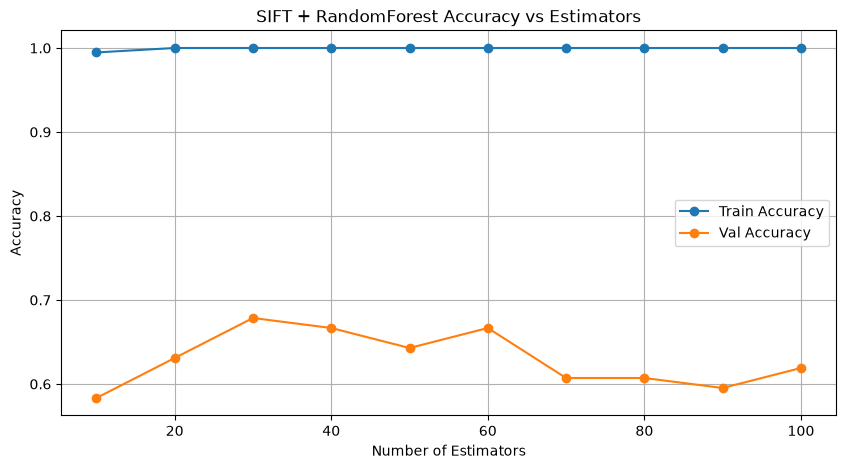

In [9]:

# Plot Accuracy/Loss Curves vs. Number of Estimators (Trees)
print("Evaluating model performance vs number of estimators...")
estimators_range = range(10, 101, 10)
train_accs = []
val_accs = []

for n in estimators_range:
    clf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    clf.fit(X_train_fused, y_train)
    train_accs.append(clf.score(X_train_fused, y_train))
    val_accs.append(clf.score(X_val_fused, y_val))

plt.figure(figsize=(10, 5))
plt.plot(estimators_range, train_accs, 'o-', label='Train Accuracy')
plt.plot(estimators_range, val_accs, 'o-', label='Val Accuracy')
plt.title(f'{FEATURE_NAME} + {CLASSIFIER_NAME} Accuracy vs Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()


## 8. Learning Curves
Shows training and validation accuracy vs. size of dataset subset.

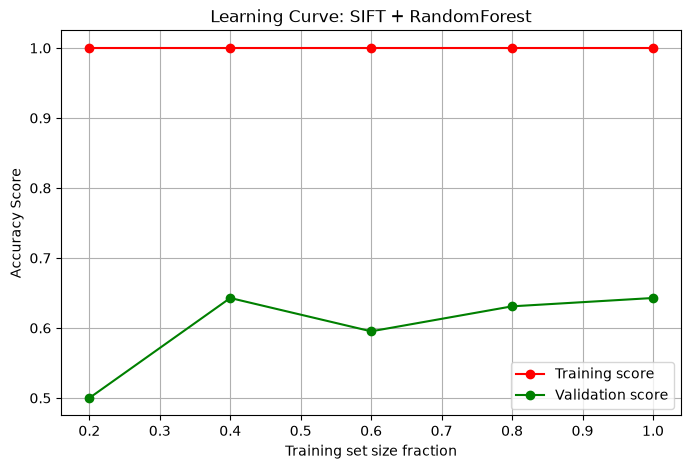

In [10]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_train = []
lc_val = []

for size in train_sizes:
    n_samples = int(size * len(X_train_fused))
    if n_samples < 10:
        n_samples = 10
    X_sub = X_train_fused[:n_samples]
    y_sub = y_train[:n_samples]
    
    if CLASSIFIER_NAME == "RandomForest":
        clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    else:
        clf = XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=4, eval_metric='mlogloss', random_state=42, n_jobs=-1)
        
    clf.fit(X_sub, y_sub)
    lc_train.append(clf.score(X_sub, y_sub))
    lc_val.append(clf.score(X_val_fused, y_val))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, lc_train, 'o-', color="r", label="Training score")
plt.plot(train_sizes, lc_val, 'o-', color="g", label="Validation score")
plt.title(f"Learning Curve: {FEATURE_NAME} + {CLASSIFIER_NAME}")
plt.xlabel("Training set size fraction")
plt.ylabel("Accuracy Score")
plt.grid(True)
plt.legend()
plt.show()